# Plot Time Series of Temperature, Electricity Demand, and Generation for a Given Event


In [1]:
# Start by importing the packages we need:
import os
import datetime
import yaml

import pandas as pd
import matplotlib.pyplot as plt


## Set Root Directory

All paths used in this notebook branch off a root directory controlled by a master file `root_directory.yml` stored in the `/notebooks` directory.


In [2]:
# Read the yml file and extract the root directory
with open('root_directory.yml', 'r') as file:
    root_dir = yaml.safe_load(file)
       
# Return the root directory:
root_dir


'/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_applied_energy'

## Set the Directory Structure

In [3]:
# Identify the data input and output directories:
hw_cs_data_dir = (root_dir + '/data/thermal_events_data/')
integrated_time_series_data_input_dir = (root_dir + '/data/integrated_time_series/')
image_output_dir = (root_dir + '/figures/case_study_results/')


## Make the Plot


In [4]:
def plot_hw_event_time_series(hw_cs: str, event: str, window: int, hw_cs_data_dir: str, integrated_time_series_data_input_dir: str, 
                              image_output_dir: str, image_resolution: int, save_images=False):

    # Read in the heat wave or cold snap event library:
    if hw_cs == 'HW': 
       hw_cs_df = pd.read_csv((hw_cs_data_dir + 'hw_library_expanded.csv'))
    else:
       hw_cs_df = pd.read_csv((hw_cs_data_dir + 'cs_library_expanded.csv'))
        
    # Subset to just the event specified:
    hw_cs_df = hw_cs_df.loc[hw_cs_df['UID'] == event].copy()

    # Extract the event parameters used to query the functions defined above:
    region = hw_cs_df.loc[hw_cs_df['UID'] == event, 'Region'].item()
    start_date = pd.to_datetime(hw_cs_df.loc[hw_cs_df['UID'] == event, 'Start'].item())
    end_date = pd.to_datetime(hw_cs_df.loc[hw_cs_df['UID'] == event, 'End'].item())
    start_date_shading = start_date - pd.Timedelta(days=0.5)
    end_date_shading = end_date + pd.Timedelta(days=0.5)

    # Create the region name to be used in the plot:
    if region == 'CA':
       region_name = 'California'
    if region == 'GB':
       region_name = 'Great Basin'
    if region == 'PNW':
       region_name = 'Pacific Northwest'    
    if region == 'RM':
       region_name = 'Rocky Mountains'
    if region == 'SW':
       region_name = 'Southwest'
        
    # Read in the integrated time series and subset the data to just dates within the time window:
    event_df = pd.read_csv((integrated_time_series_data_input_dir + region + '_Integrated_Time_Series_1982_to_2019.csv'))
    event_df['Time_UTC'] = pd.to_datetime(event_df['Time_UTC'])
    event_df = event_df[(event_df['Time_UTC'] >= pd.to_datetime((start_date - pd.Timedelta(days=window)))) & (event_df['Time_UTC'] <= pd.to_datetime((end_date + pd.Timedelta(days=window))))].copy()

    # Convert the loads from MW to GW:
    event_df['Region_Load'] = event_df['Region_Load'] / 1000
    event_df['Region_Load_Mean'] = event_df['Region_Load_Mean'] / 1000
    event_df['WECC_Load'] = event_df['WECC_Load'] / 1000
    event_df['WECC_Load_Mean'] = event_df['WECC_Load_Mean'] / 1000

    # Convert temperatures from F to C:
    event_df['T_Max'] = (event_df['T_Max']-32)/(9/5)
    event_df['T_Max_Mean'] = (event_df['T_Max_Mean']-32)/(9/5)
    event_df['T_Min'] = (event_df['T_Min']-32)/(9/5)
    event_df['T_Min_Mean'] = (event_df['T_Min_Mean']-32)/(9/5)
    
    # Calculate the minimum and maximum values to be used in plotting:
    if hw_cs == 'HW':
       temp_min = min([event_df['T_Max'].min(),event_df['T_Max_Mean'].min()]) - 1
       temp_max = max([event_df['T_Max'].max(),event_df['T_Max_Mean'].max()]) + 1
    else:
       temp_min = min([event_df['T_Min'].min(),event_df['T_Min_Mean'].min()]) - 1
       temp_max = max([event_df['T_Min'].max(),event_df['T_Min_Mean'].max()]) + 1
    region_load_min = min([event_df['Region_Load'].min(),event_df['Region_Load_Mean'].min()]) * 0.9
    region_load_max = max([event_df['Region_Load'].max(),event_df['Region_Load_Mean'].max()]) * 1.1
    wecc_load_min = min([event_df['WECC_Load'].min(),event_df['WECC_Load_Mean'].min()]) * 0.9
    wecc_load_max = max([event_df['WECC_Load'].max(),event_df['WECC_Load_Mean'].max()]) * 1.1
    if event_df['Imports'].min() < 0:
       imports_min = event_df['Imports'].min() * 1.1
    else:
       imports_min = event_df['Imports'].min() * 0.9 
    if event_df['Imports'].max() < 0:    
       imports_max = event_df['Imports'].max() * 0.9
    else:
       imports_max = event_df['Imports'].max() * 1.1 
        
    # Set the fill color:
    if hw_cs == 'HW':
       fill_color = 'r'
       line_color = 'r' 
    else:
       fill_color = 'b'
       line_color = 'b' 
        
    # Make the plot:
    plt.figure(figsize=(25,30))
    plt.rcParams['font.size'] = 18
    plt.rcParams['axes.axisbelow'] = True
    
    ax1 = plt.subplot(511)
    if hw_cs == 'HW':
       plt.plot(event_df['Time_UTC'], event_df['T_Max'], color=line_color, linestyle='-', linewidth=3, label='Event')
       plt.plot(event_df['Time_UTC'], event_df['T_Max_Mean'], color='k', linestyle='--', linewidth=2, label='Long-Term Average')
    else:
       plt.plot(event_df['Time_UTC'], event_df['T_Min'], color=line_color, linestyle='-', linewidth=3, label='Event')
       plt.plot(event_df['Time_UTC'], event_df['T_Min_Mean'], color='k', linestyle='--', linewidth=2, label='Long-Term Average') 
    plt.fill_between([pd.to_datetime(start_date_shading), pd.to_datetime(end_date_shading)], temp_min, temp_max, color=fill_color, alpha=0.15)
    plt.legend(loc='upper left', prop={'size': 15})
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([temp_min, temp_max])
    if hw_cs == 'HW':
       plt.ylabel('Temperature [$^\circ$C]', fontsize=18)
       plt.title(('Daily Maximum Temperature in ' + region_name))
    else:
       plt.ylabel('Temperature [$^\circ$C]', fontsize=18)
       plt.title(('Daily Minimum Temperature in ' + region_name))

    ax2 = plt.subplot(512)
    plt.plot(event_df['Time_UTC'], event_df['Region_Load'], color=line_color, linestyle='-', linewidth=3, label='Event')
    plt.plot(event_df['Time_UTC'], event_df['Region_Load_Mean'], color='k', linestyle='--', linewidth=2, label='Long-Term Average')
    plt.fill_between([pd.to_datetime(start_date_shading), pd.to_datetime(end_date_shading)], region_load_min, region_load_max, color=fill_color, alpha=0.15)
    plt.legend(loc='upper left', prop={'size': 15})
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([region_load_min, region_load_max])
    plt.ylabel('Regional Demand [GW]', fontsize=18)
    plt.title(('Hourly Electricity Demand in ' + region_name))

    ax3 = plt.subplot(513)
    plt.plot(event_df['Time_UTC'], event_df['WECC_Load'], color=line_color, linestyle='-', linewidth=3, label='Event')
    plt.plot(event_df['Time_UTC'], event_df['WECC_Load_Mean'], color='k', linestyle='--', linewidth=2, label='Long-Term Average')
    plt.fill_between([pd.to_datetime(start_date_shading), pd.to_datetime(end_date_shading)], wecc_load_min, wecc_load_max, color=fill_color, alpha=0.15)
    plt.legend(loc='upper left', prop={'size': 15})
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([wecc_load_min, wecc_load_max])
    plt.ylabel('Interconnection Demand [GW]', fontsize=18)
    plt.title(('Hourly Electricity Demand in the Western Interconnection'))

    ax4 = plt.subplot(514)
    plt.plot(event_df['Time_UTC'], event_df['Imports'], color=line_color, linestyle='-', linewidth=3, label='Event')
    plt.plot([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))], [0,0], color='k', linestyle='-', linewidth=1, label='+ are Imports, - are Exports')
    plt.fill_between([pd.to_datetime(start_date_shading), pd.to_datetime(end_date_shading)], imports_min, imports_max, color=fill_color, alpha=0.15)
    plt.legend(loc='upper left', prop={'size': 15})
    plt.xlim([pd.to_datetime(start_date - pd.Timedelta(days=window)), pd.to_datetime(end_date + pd.Timedelta(days=window))])
    plt.ylim([imports_min, imports_max])
    plt.ylabel('Imports [MW]', fontsize=18)
    plt.title(('Hourly Imports into ' + region_name))
    
    ax5 = plt.subplot(515)
    event_df.plot.bar(x='Time_UTC', y=['Coal','Gas','Hydro','Other','Solar','Wind','Storage'], stacked=True, 
                      label=['Coal','Gas','Hydro','Other','Solar','Wind','Storage'],
                      color=['k','brown','b','m','r','g','c'],
                      width=0.8,
                      ax=ax5)
    plt.legend(loc='upper left', prop={'size': 12})
    plt.xticks([])
    plt.xlabel('')
    plt.ylabel('Generation [MW]', fontsize=18)
    plt.title(('Hourly Generation Mix in ' + region_name))

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       if event == 'HW_NERC1_Event14':
          filename = (os.path.join(image_output_dir + 'ST1-CA_Time_Series.png'))
       if event == 'HW_NERC1_Event67':
          filename = (os.path.join(image_output_dir + 'ST2-CA_Time_Series.png'))  
       if event == 'HW_NERC11_Event72':
          filename = (os.path.join(image_output_dir + 'SE1-PNW_Time_Series.png'))
       if event == 'HW_NERC11_Event53':
          filename = (os.path.join(image_output_dir + 'SE2-PNW_Time_Series.png'))
       if event == 'HW_NERC4_Event18':
          filename = (os.path.join(image_output_dir + 'ED1-GB_Time_Series.png'))
       if event == 'HW_NERC4_Event17':
          filename = (os.path.join(image_output_dir + 'ED2-GB_Time_Series.png'))
           
       plt.savefig(filename, dpi=image_resolution, bbox_inches='tight')


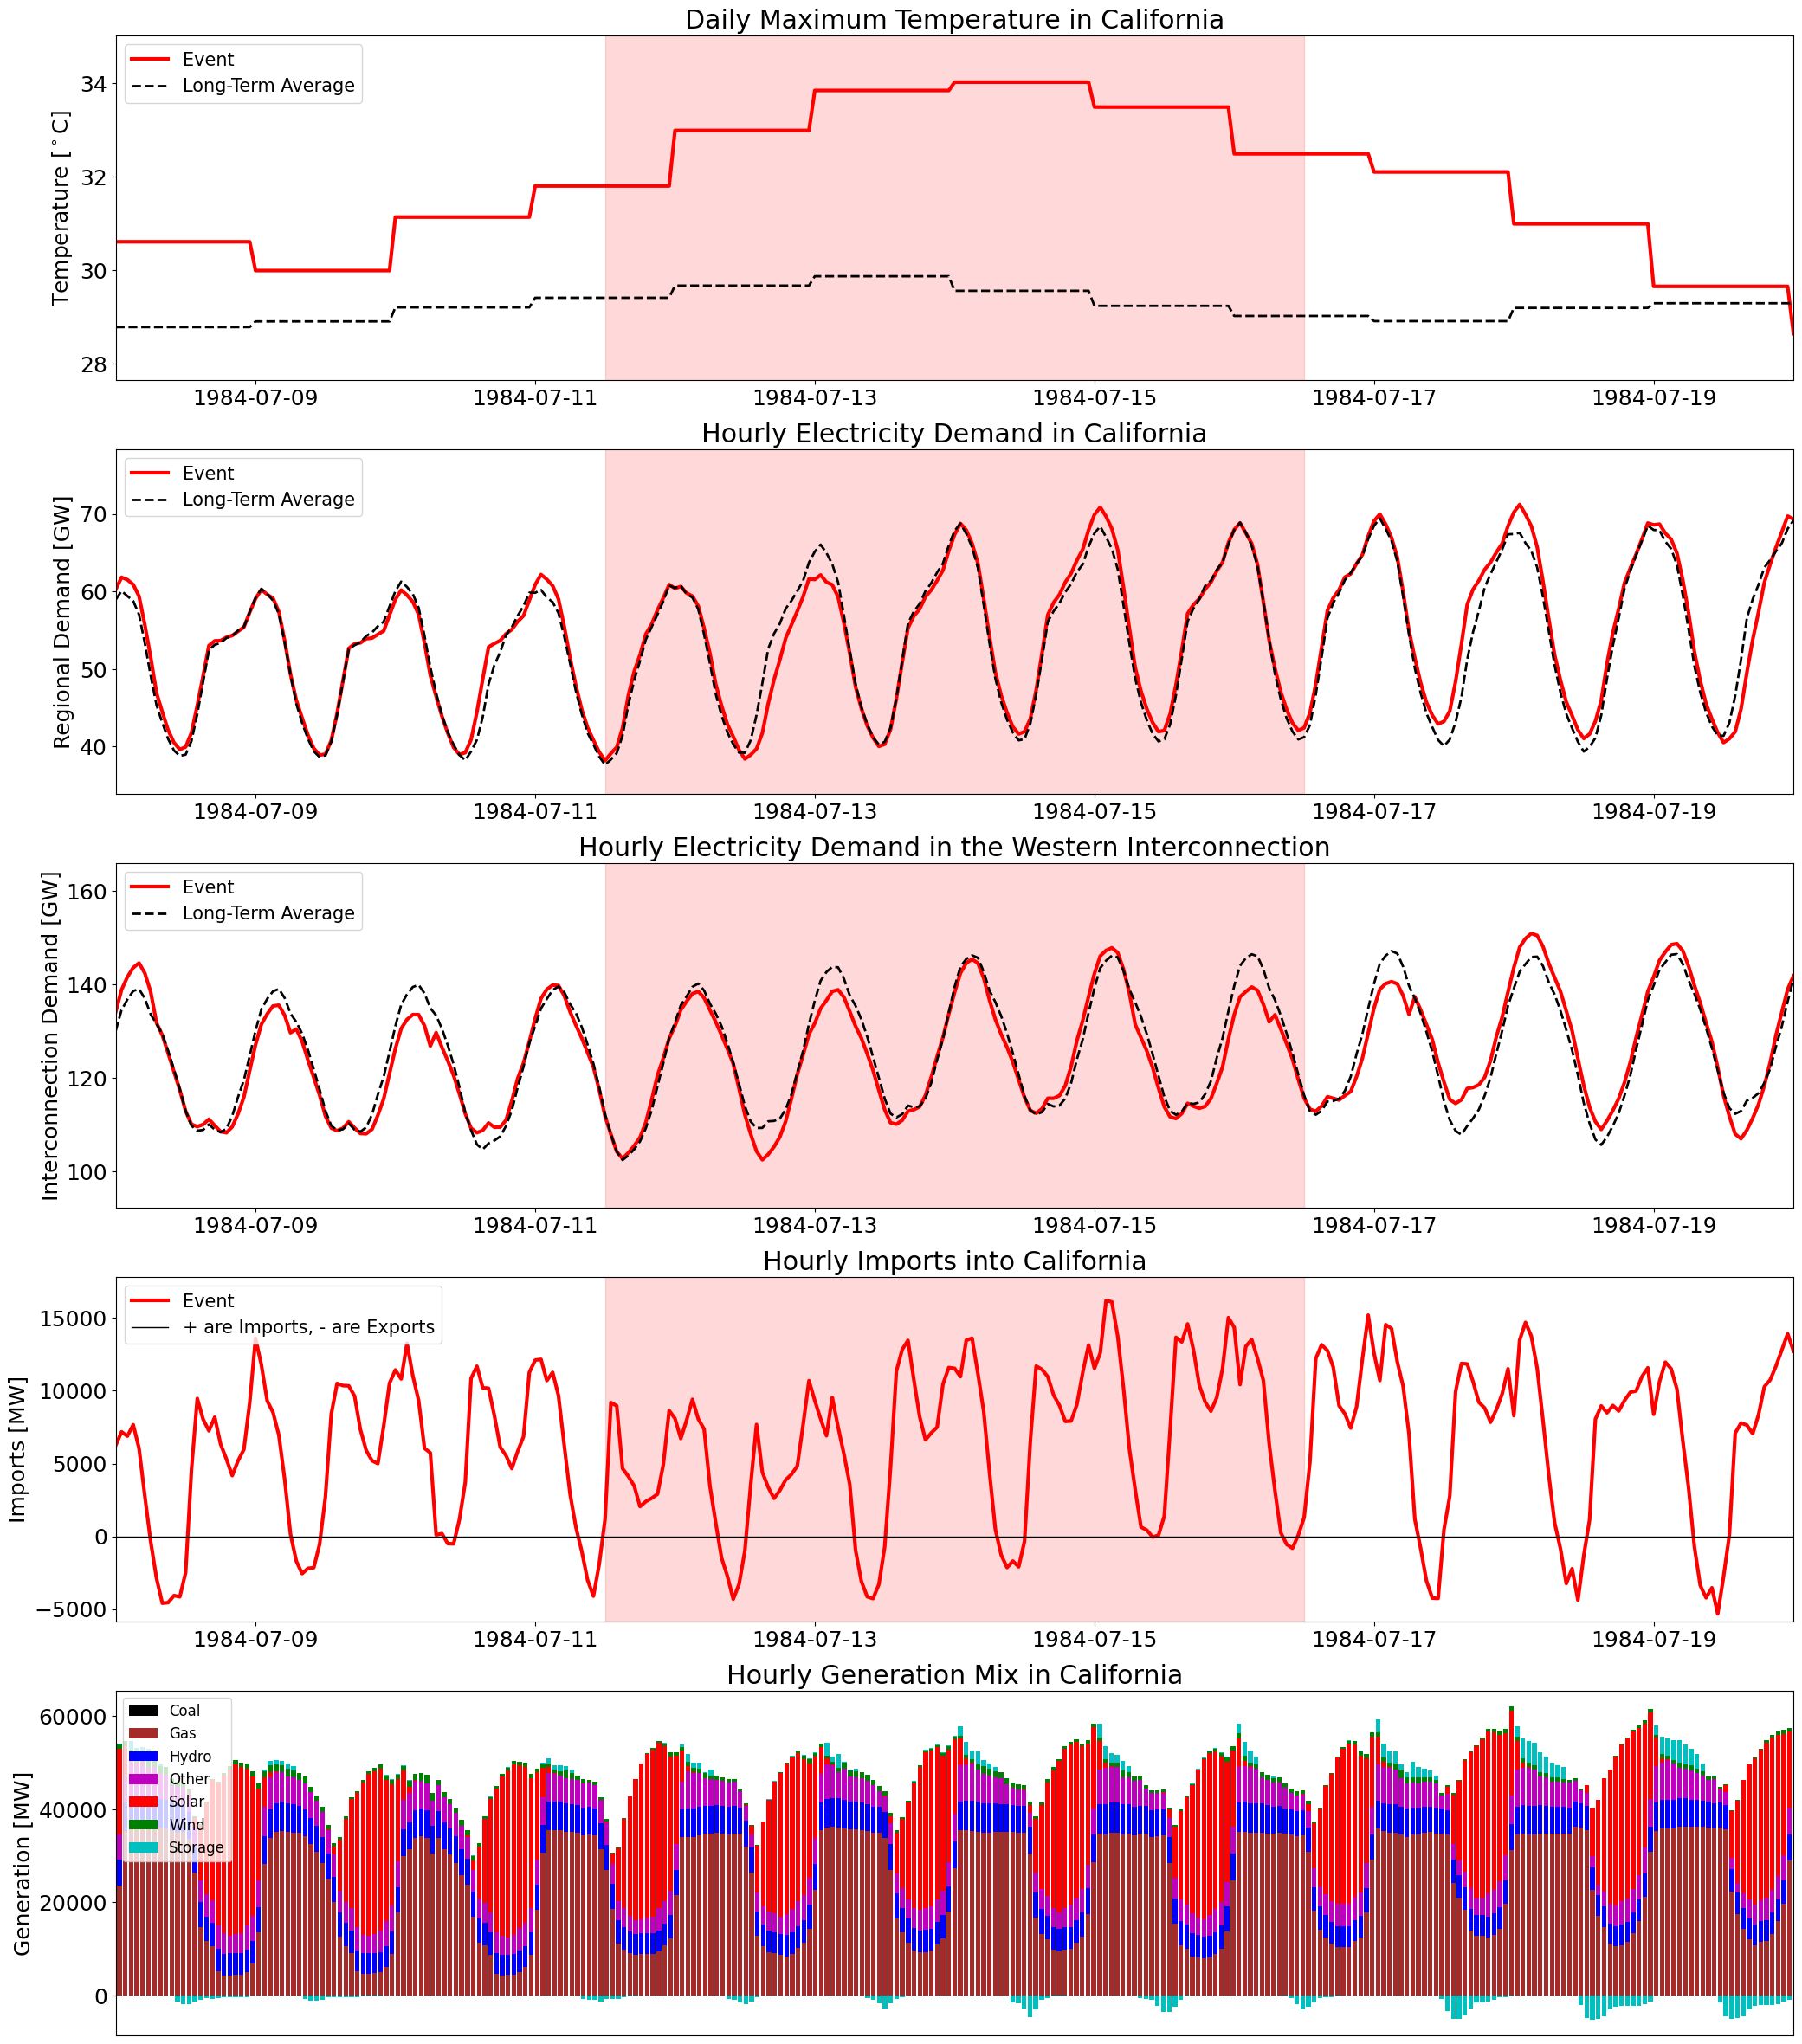

In [5]:
# Test the function:
plot_hw_event_time_series(hw_cs = 'HW',
                          event = 'HW_NERC1_Event14',
                          window = 4, # Days before and after the start of the event to make the plot
                          hw_cs_data_dir = hw_cs_data_dir,
                          integrated_time_series_data_input_dir = integrated_time_series_data_input_dir,
                          image_output_dir = image_output_dir, 
                          image_resolution = 150, 
                          save_images = False)


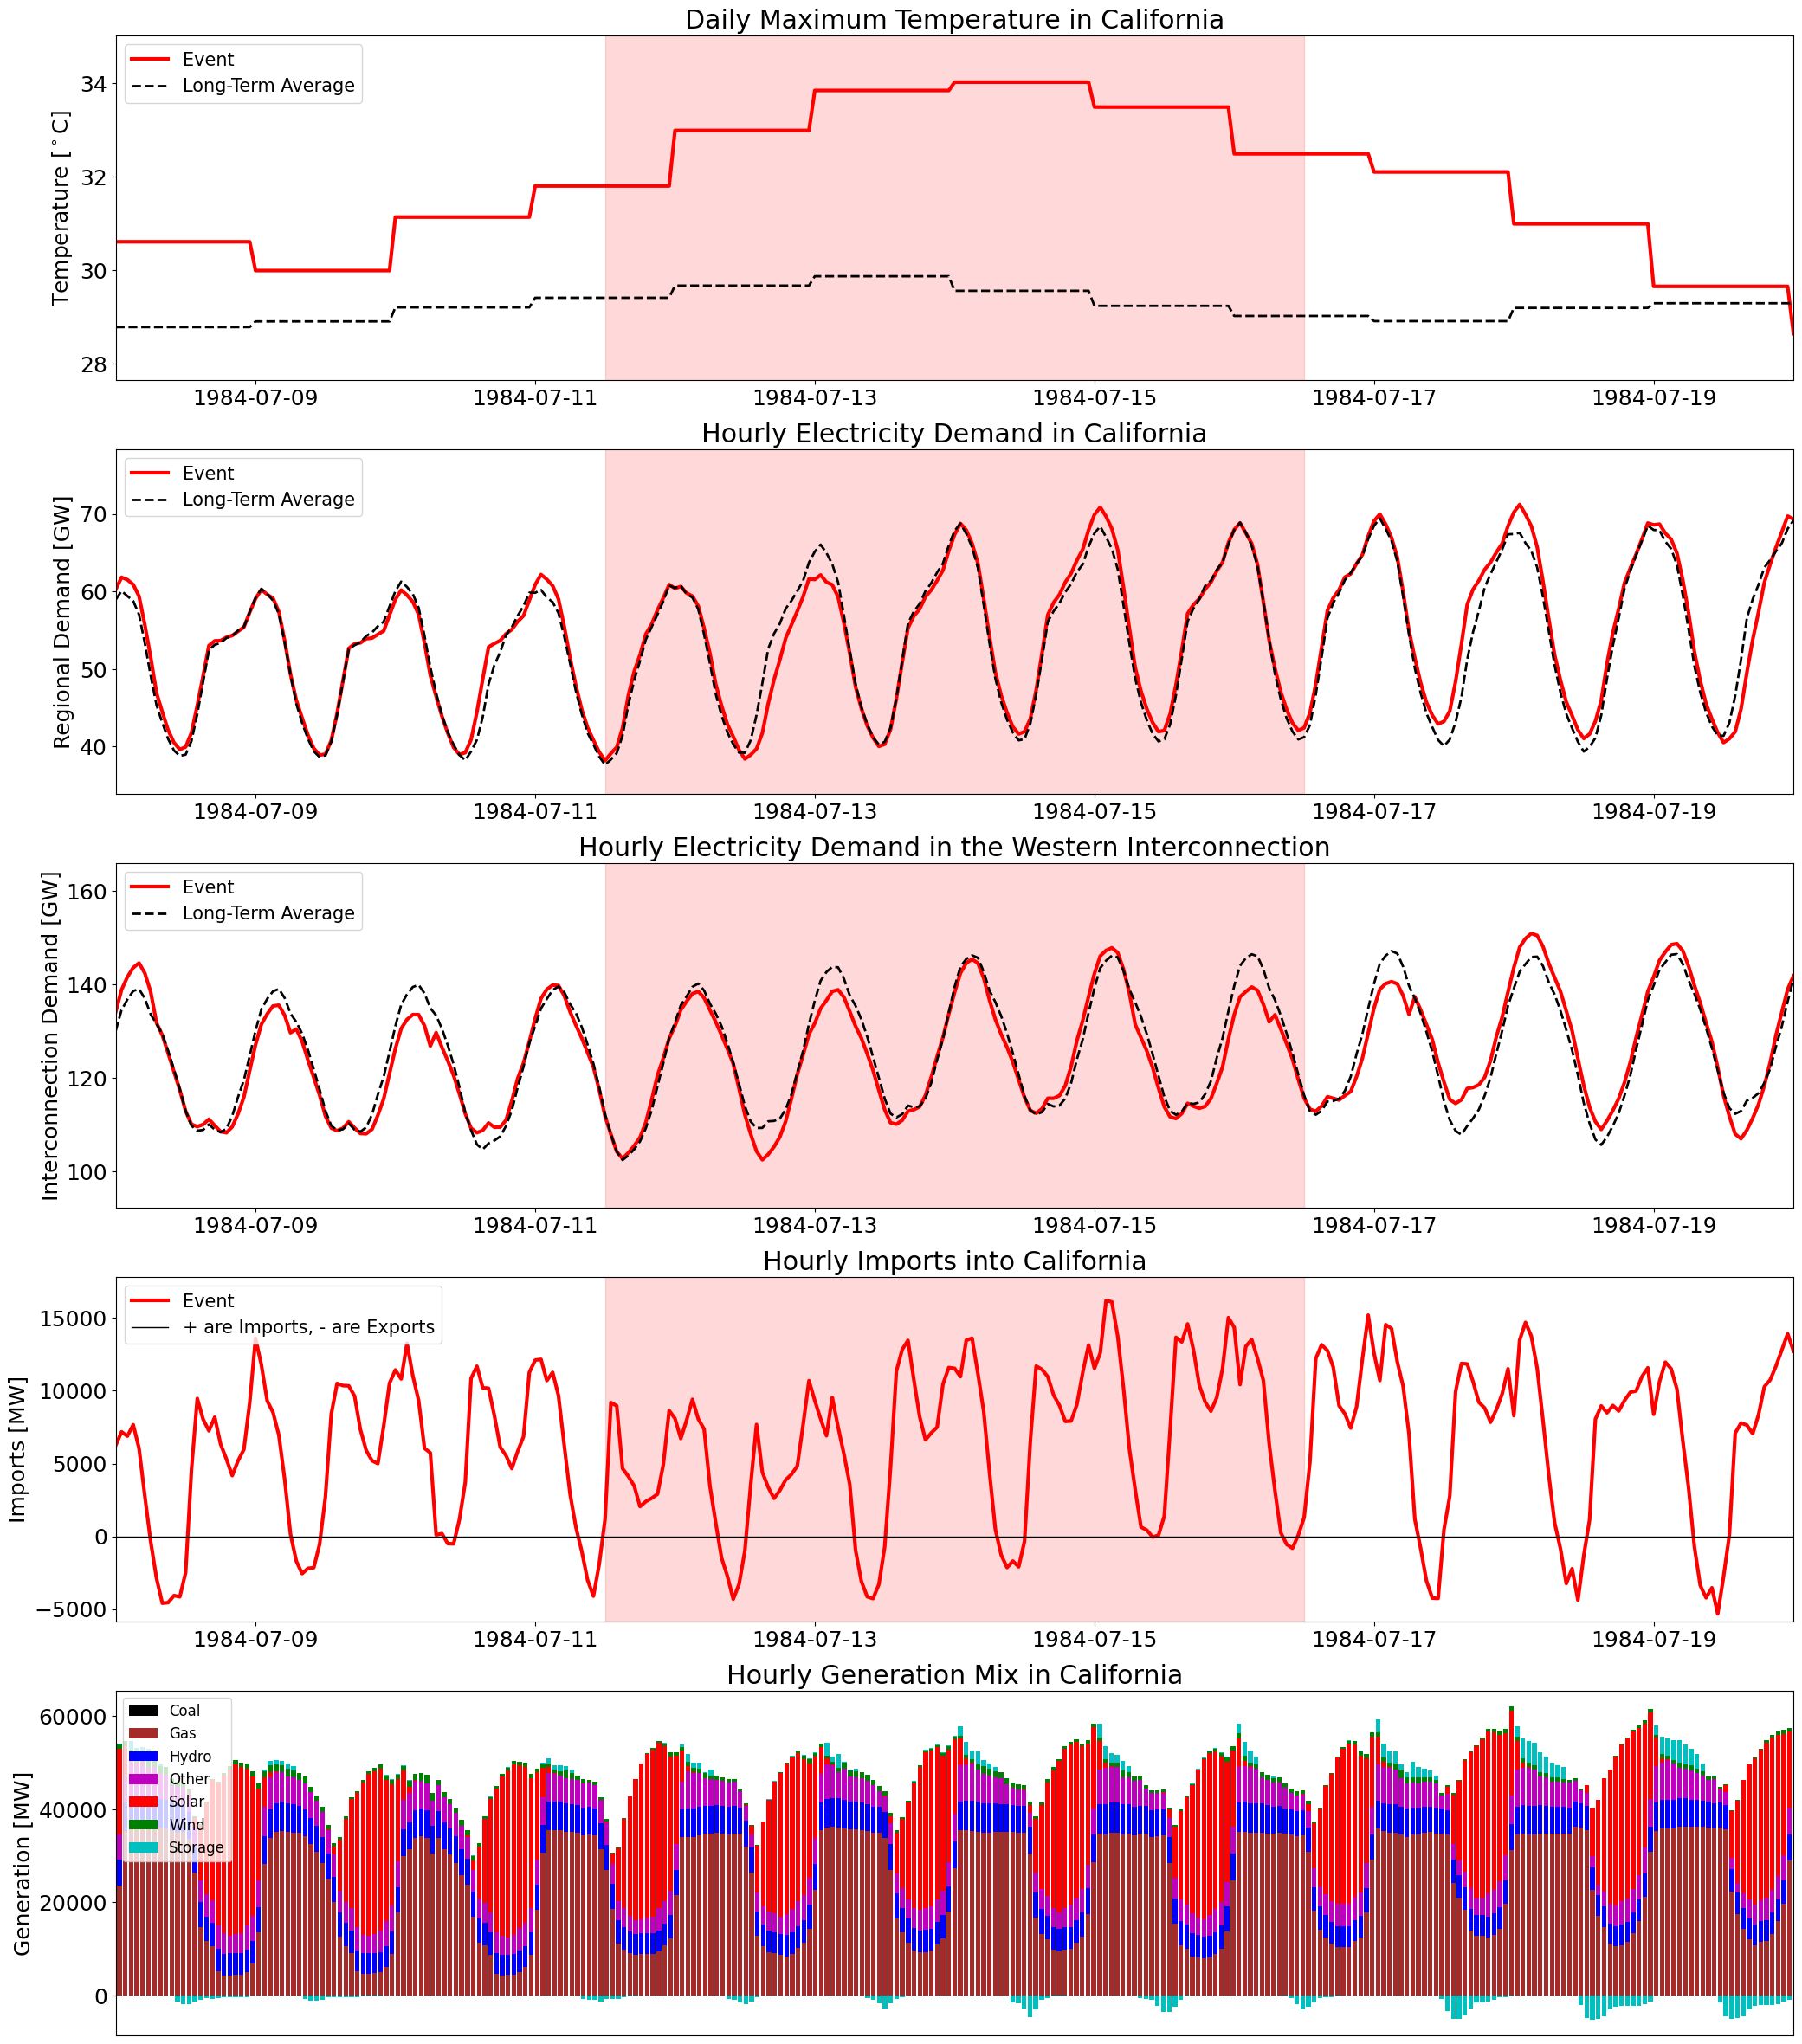

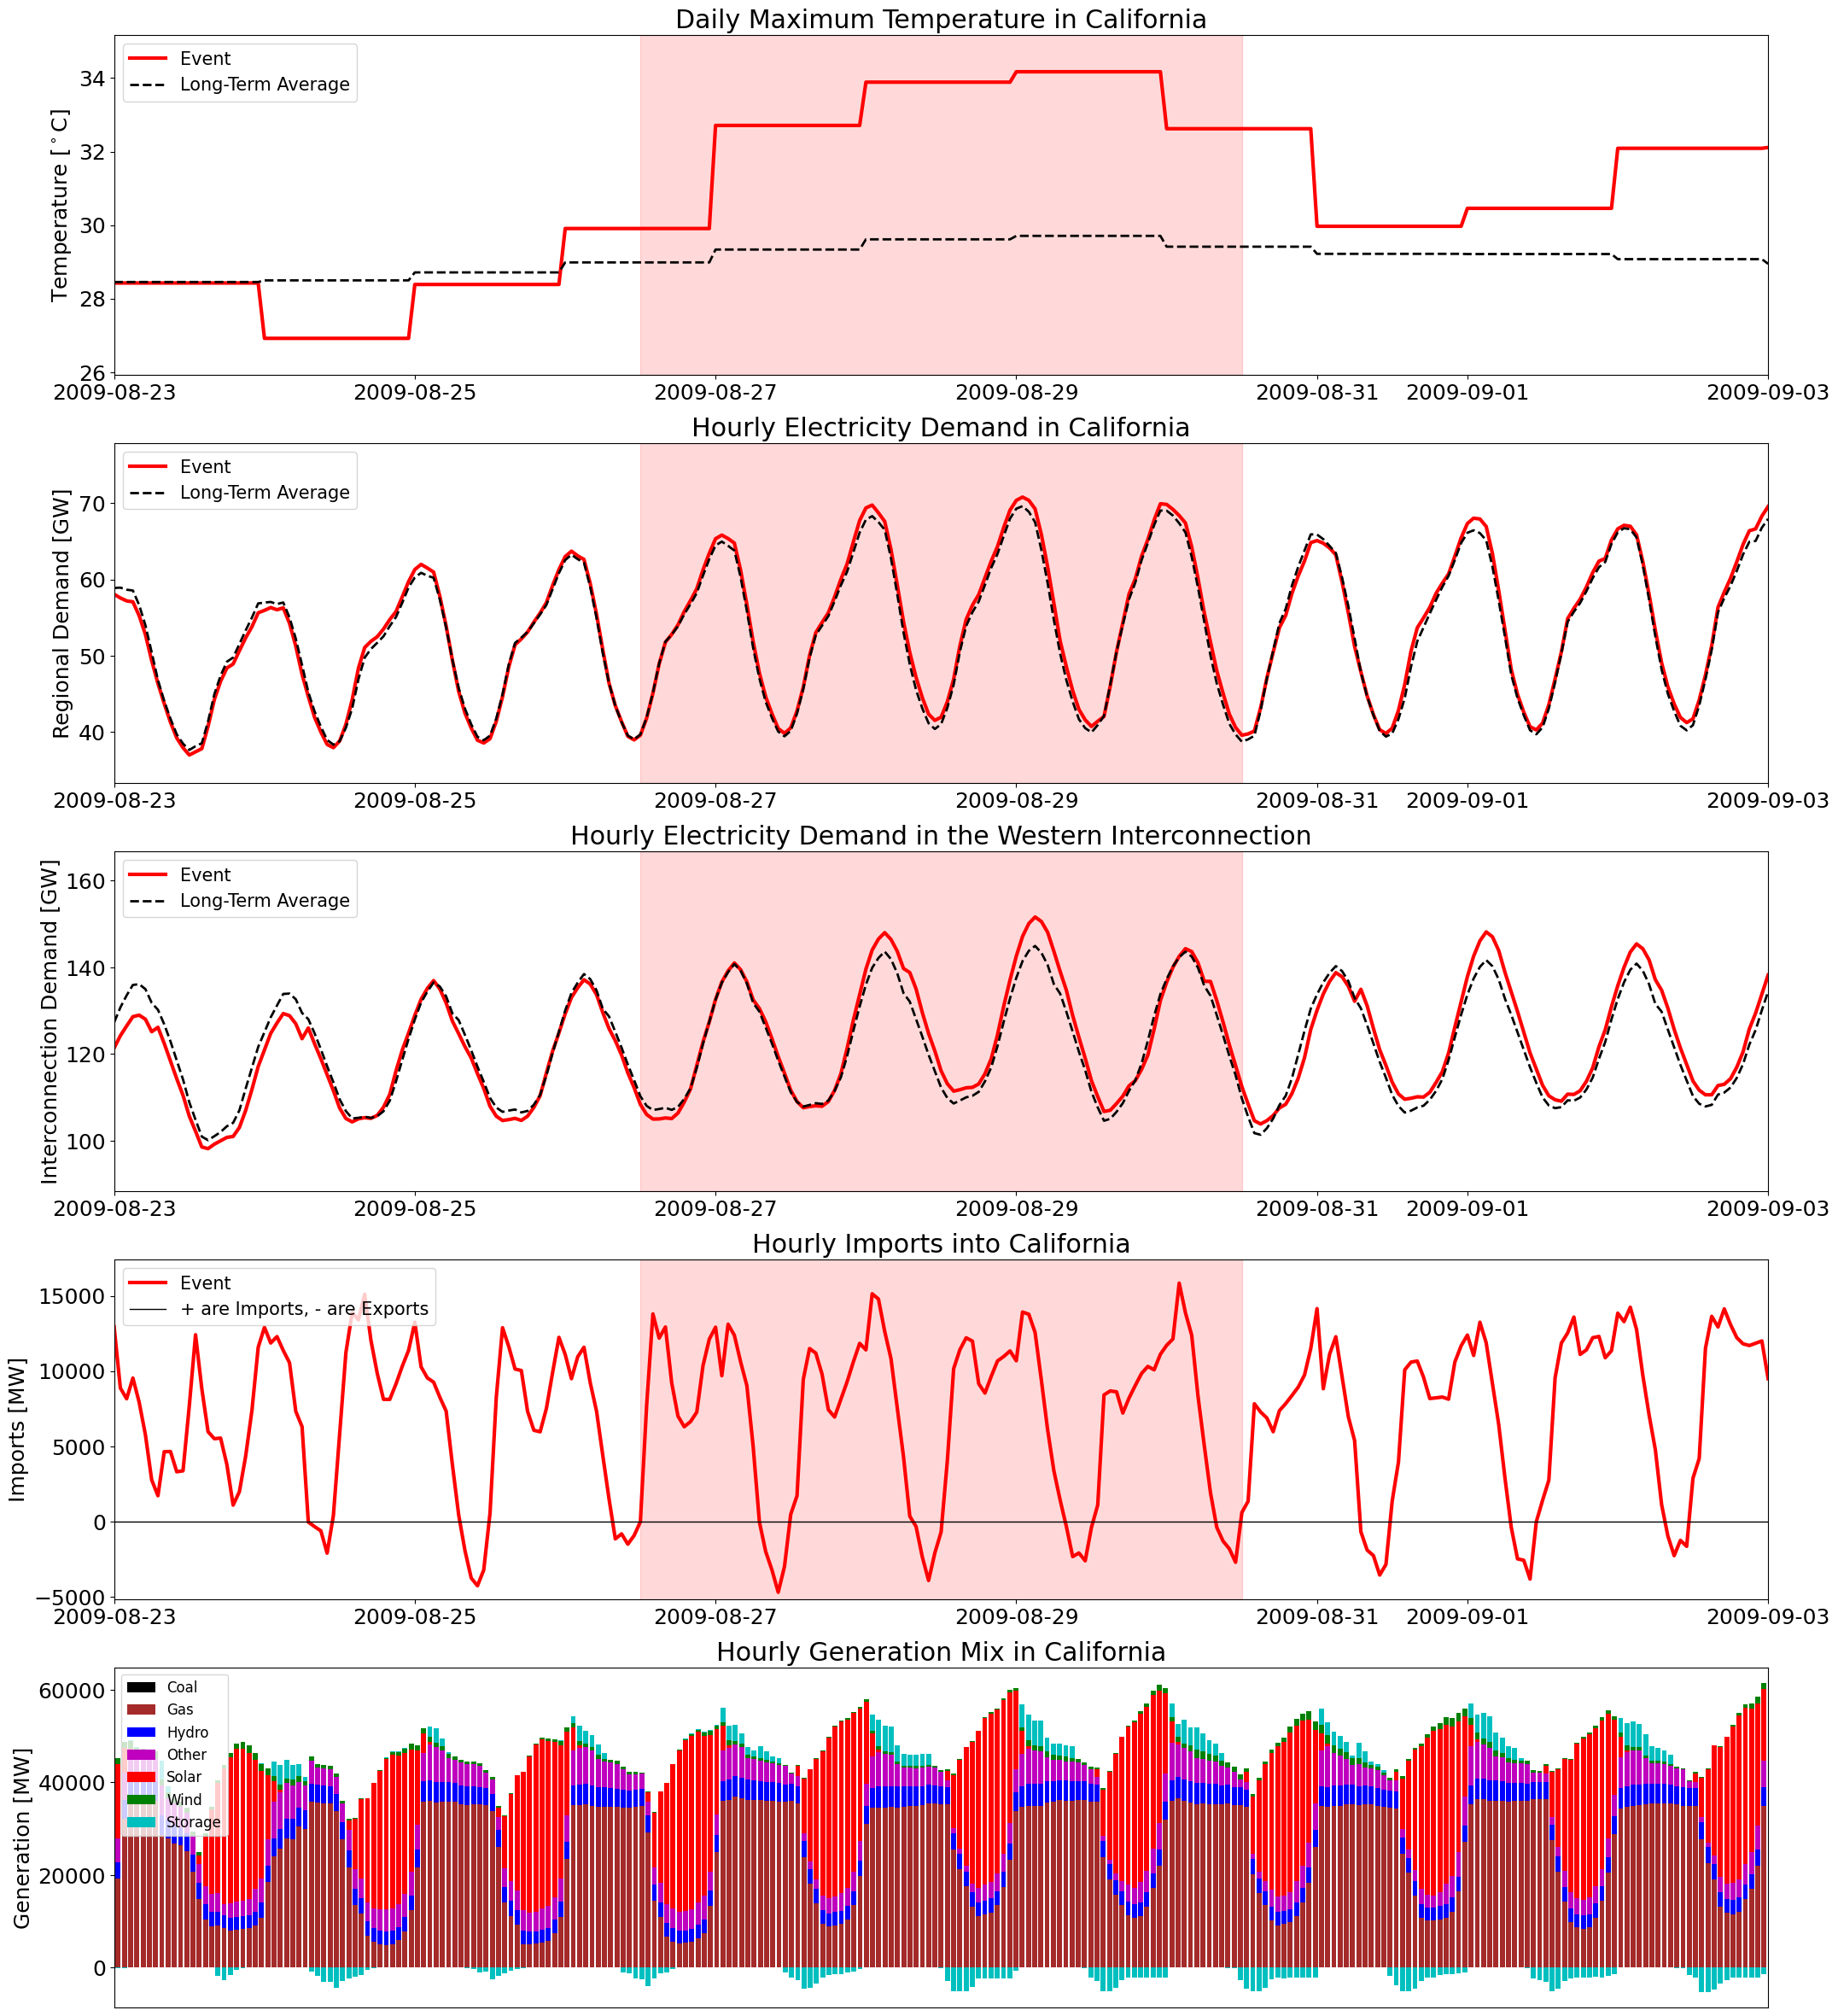

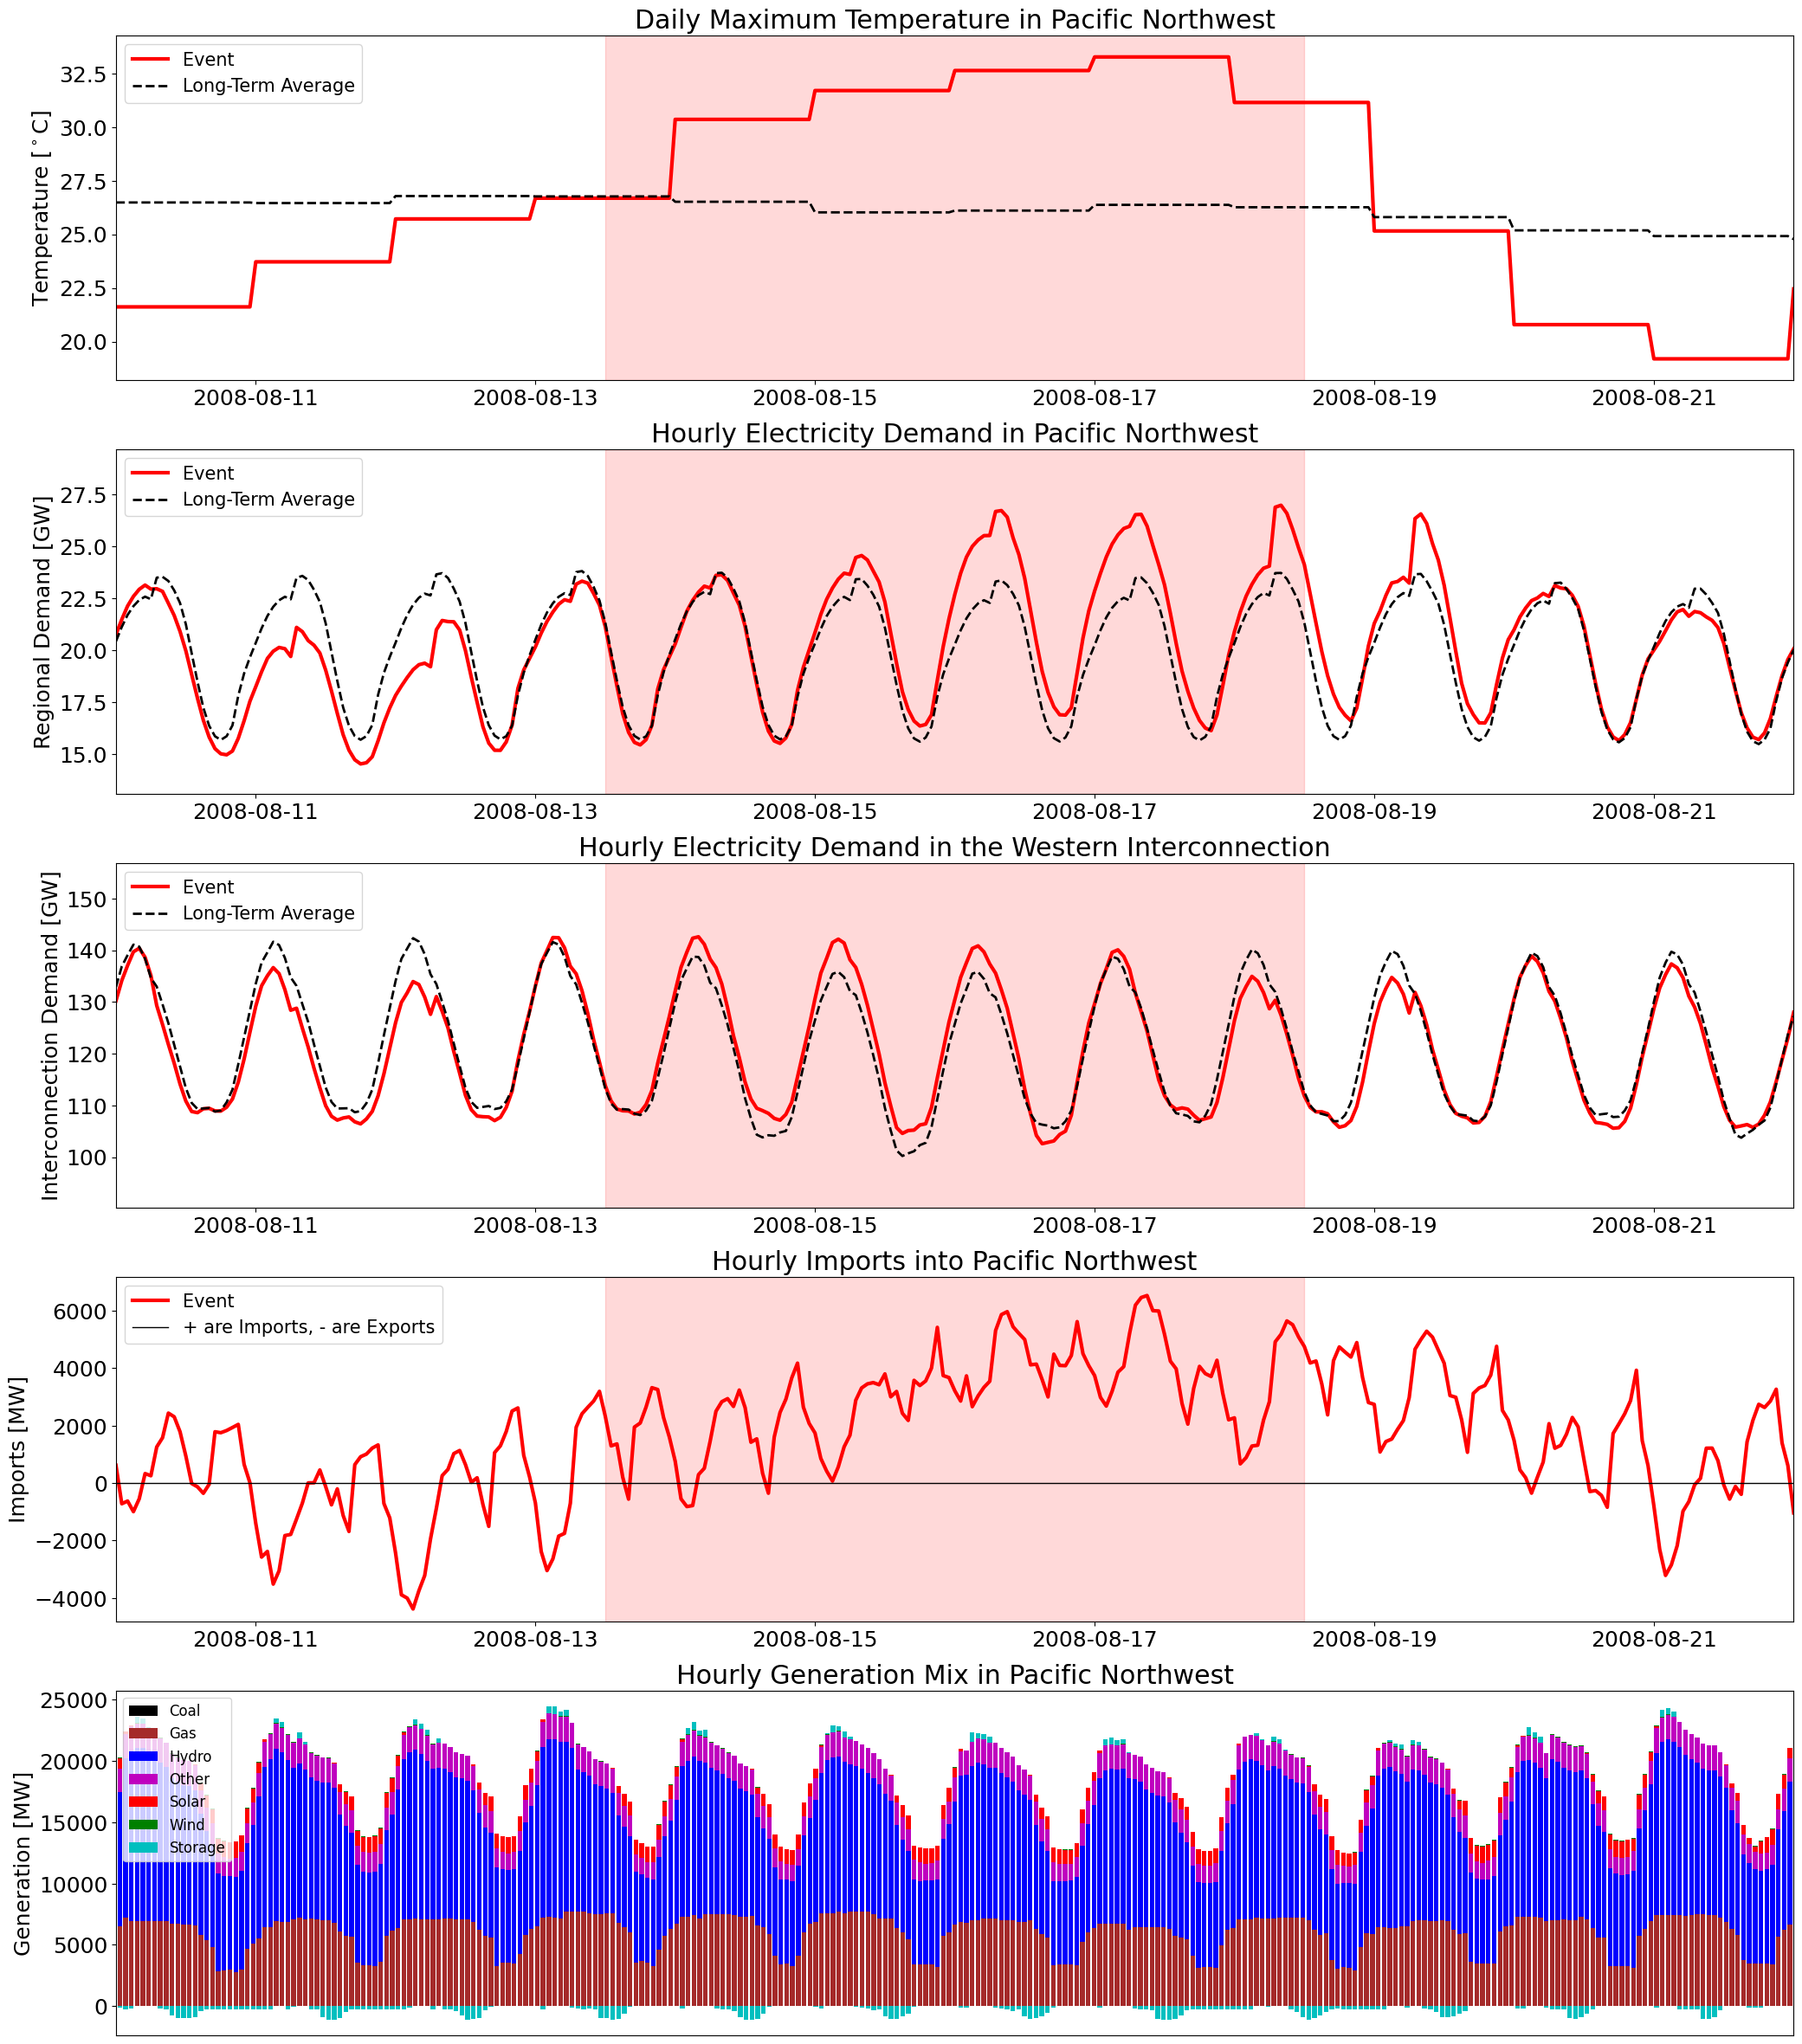

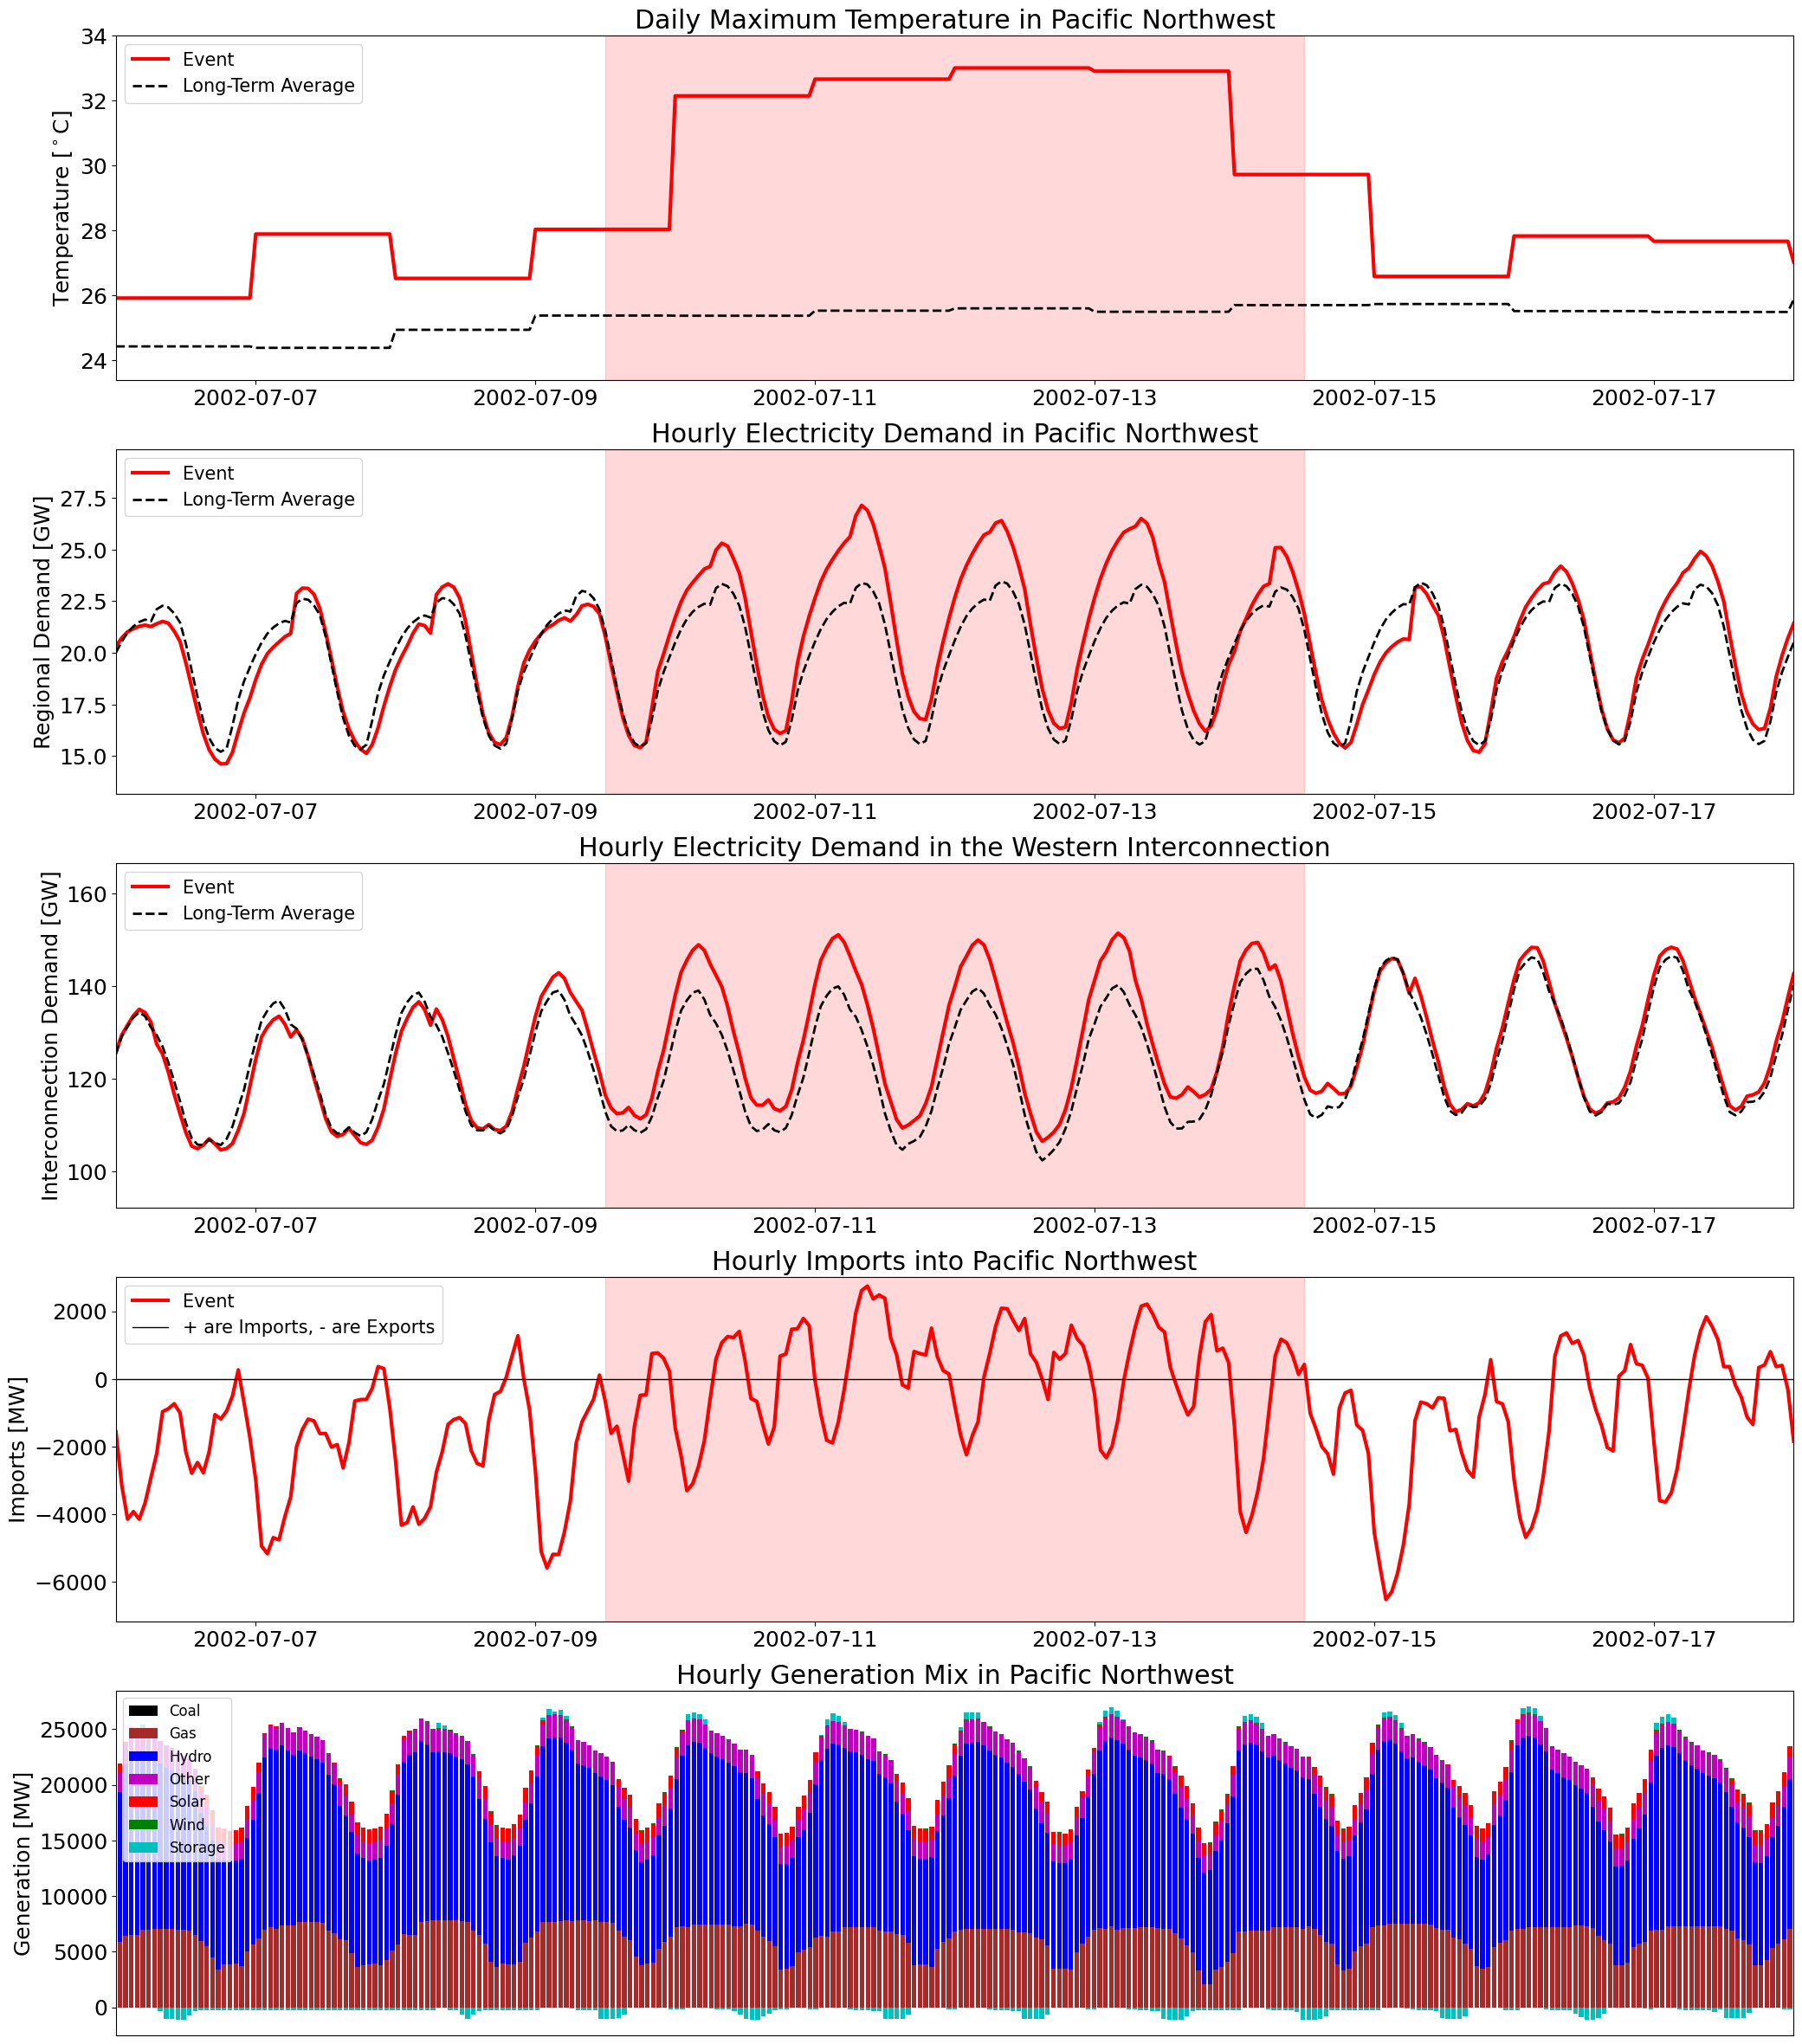

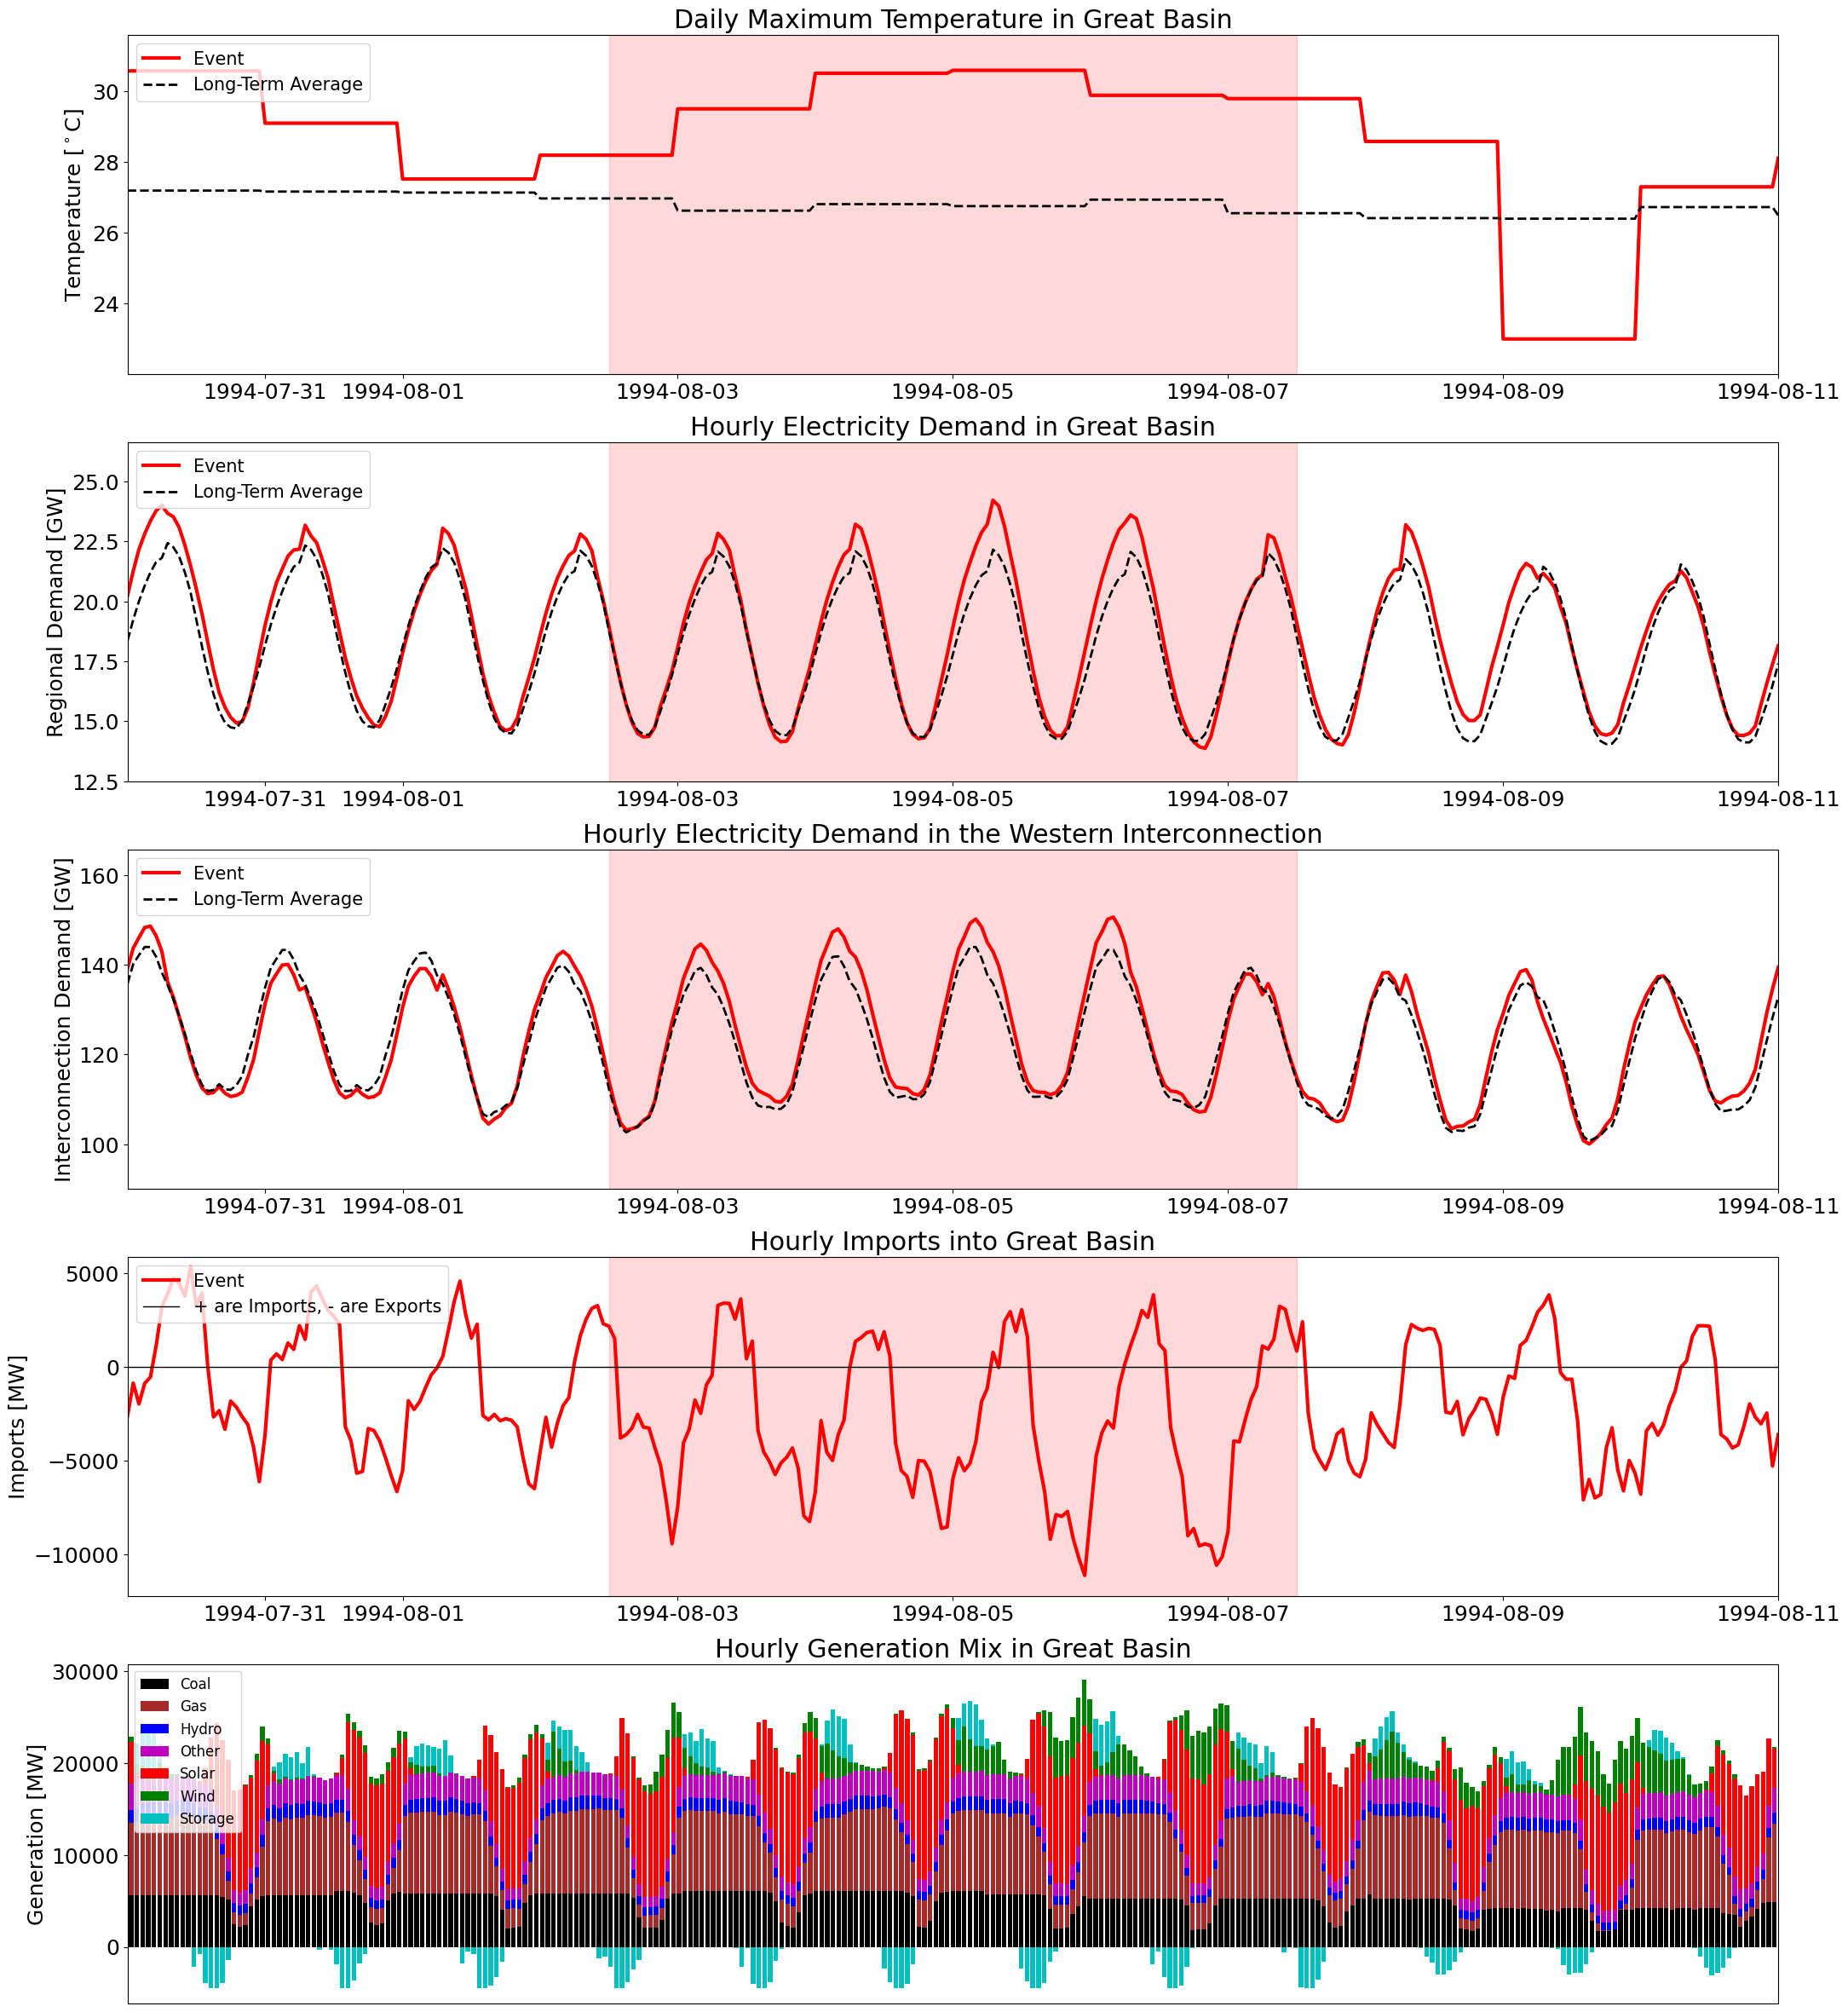

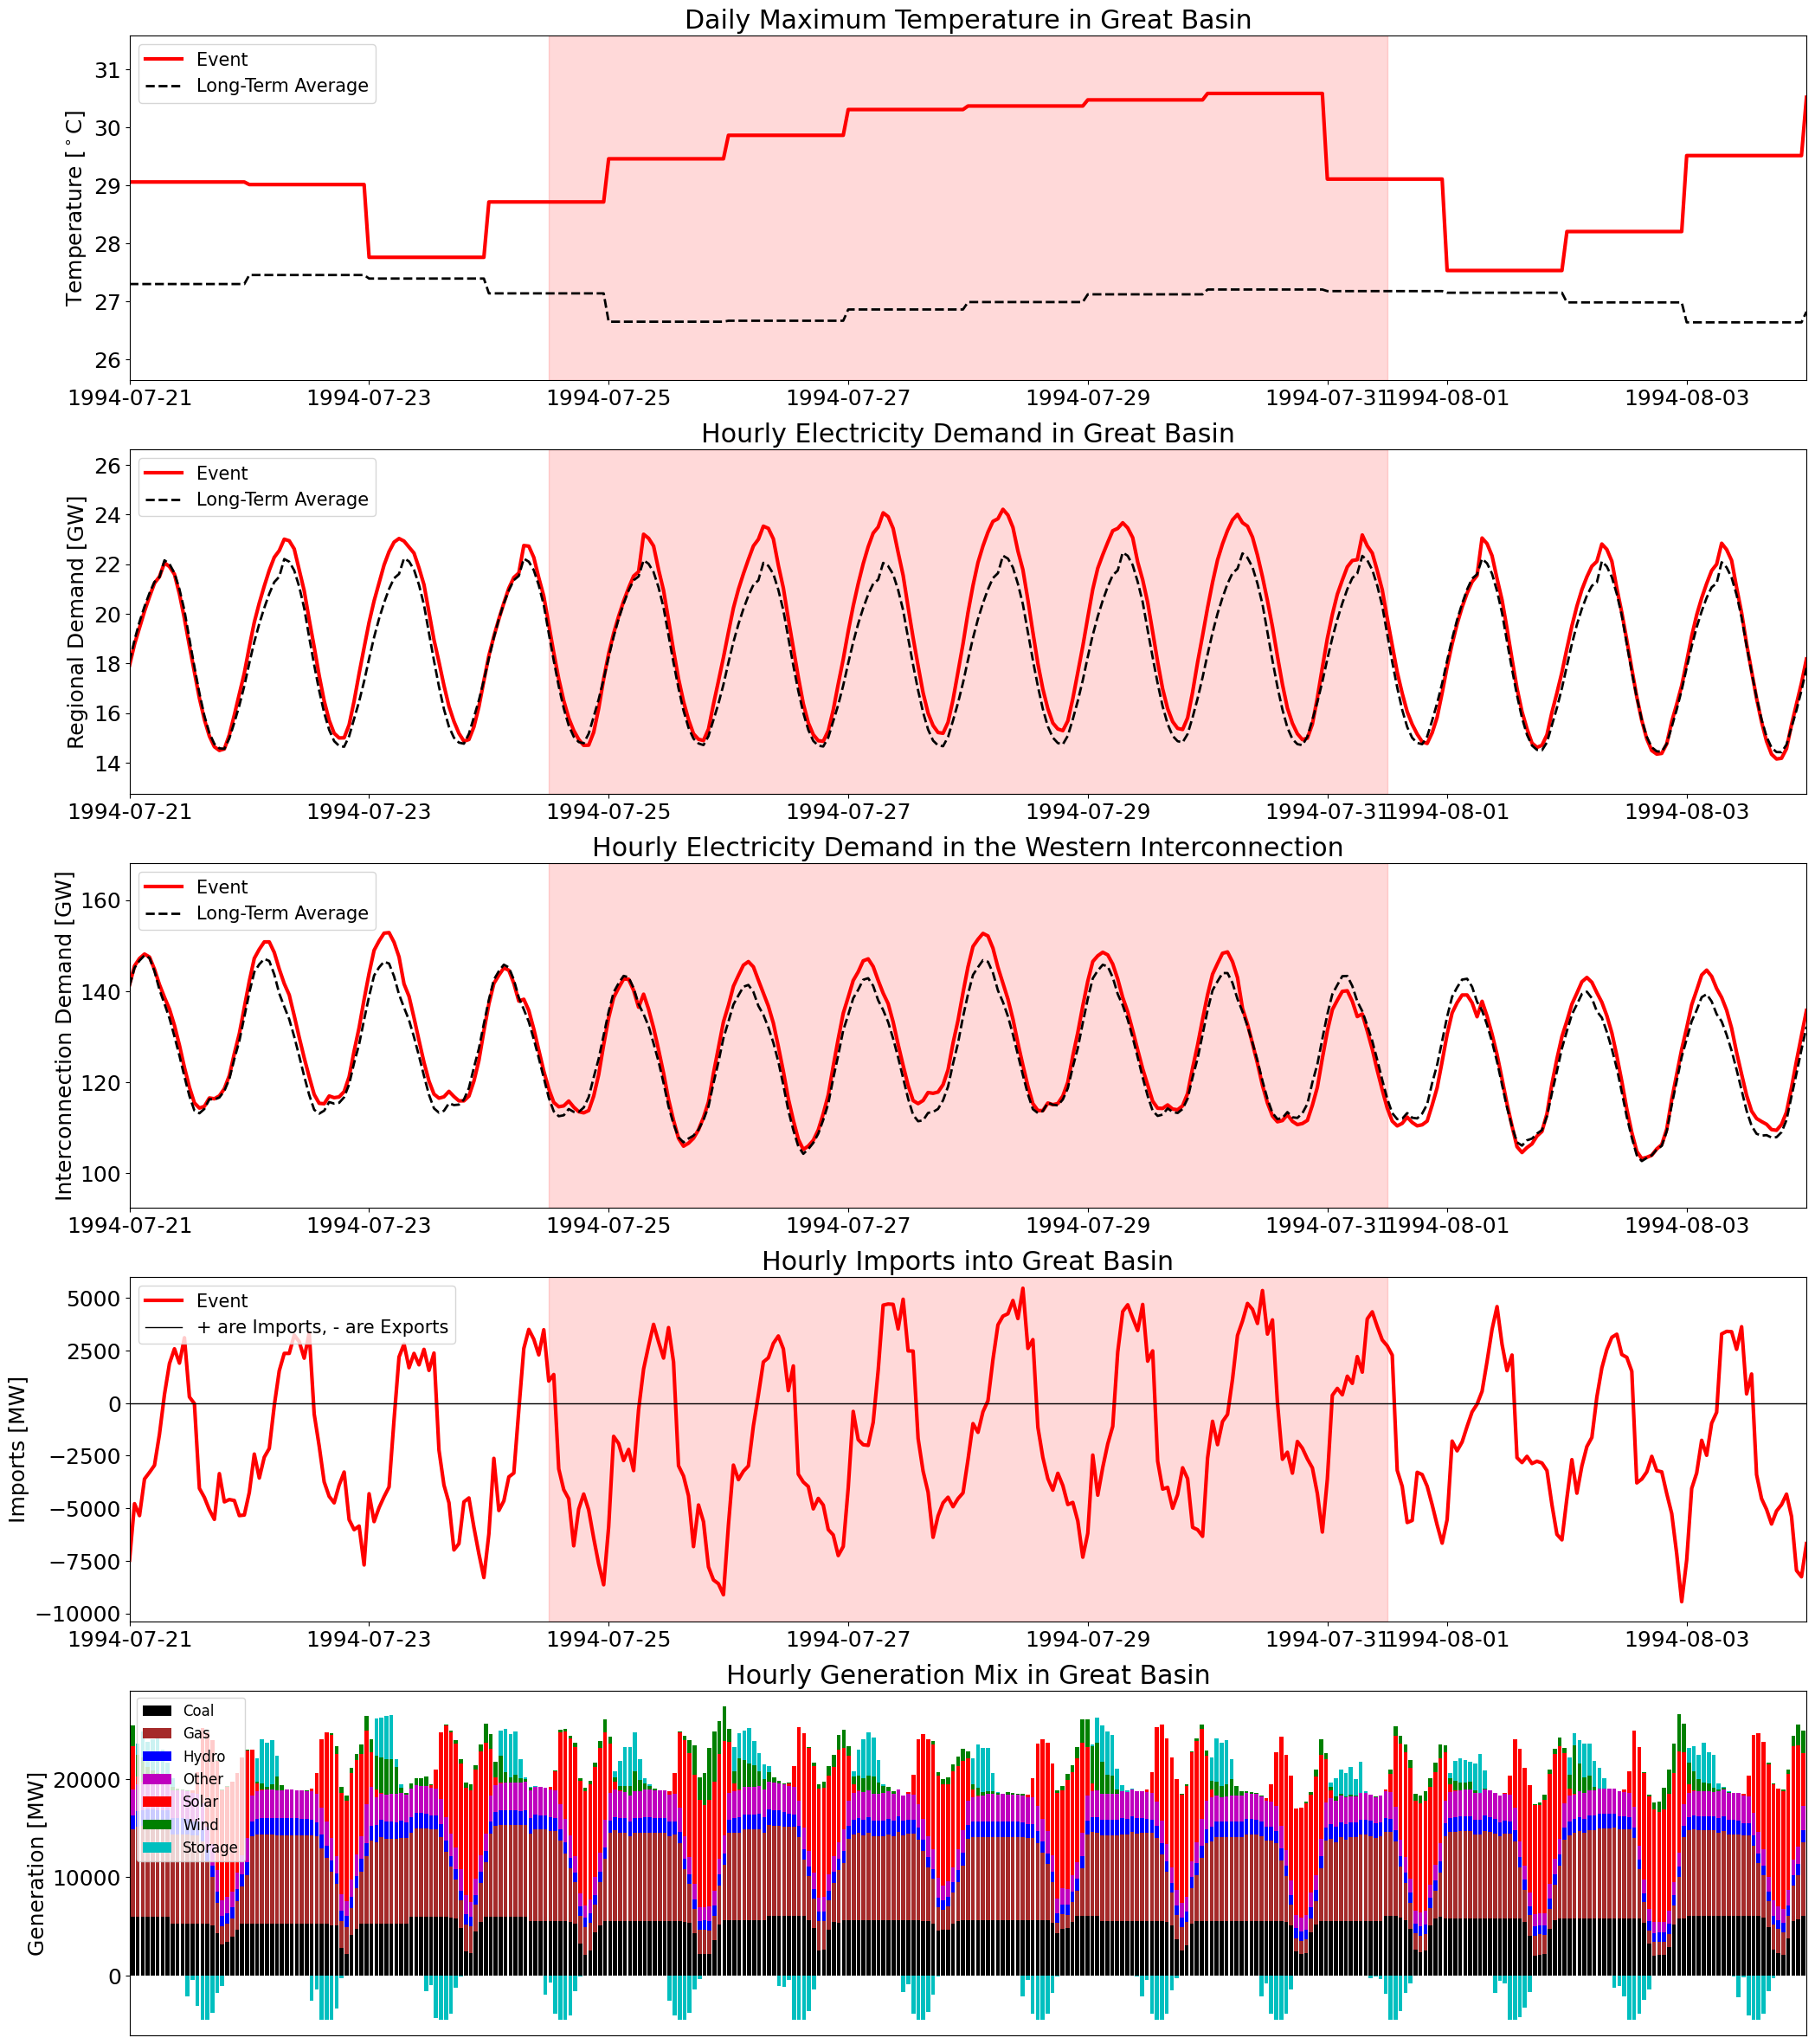

In [6]:
# Loop over the case study events and make the plot for each one:
for event_name in ['HW_NERC1_Event14', 'HW_NERC1_Event67', 'HW_NERC11_Event72', 'HW_NERC11_Event53', 'HW_NERC4_Event18', 'HW_NERC4_Event17']:
    plot_hw_event_time_series(hw_cs = 'HW',
                              event = event_name,
                              window = 4, # Days before and after the start of the event to make the plot
                              hw_cs_data_dir = hw_cs_data_dir,
                              integrated_time_series_data_input_dir = integrated_time_series_data_input_dir,
                              image_output_dir = image_output_dir, 
                              image_resolution = 150, 
                              save_images = True)
